<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

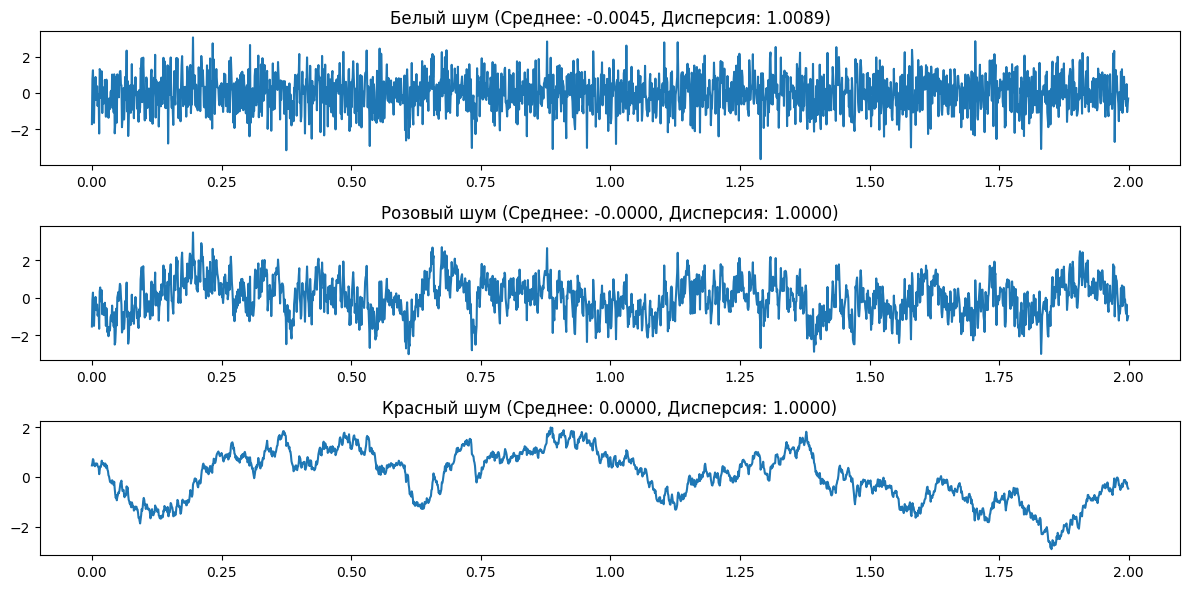

In [4]:

fs = 1000
duration = 2
N = fs * duration
t = np.arange(N) / fs

white_noise = np.random.normal(0, 1, N)

X_white = np.fft.rfft(white_noise)
freqs = np.fft.rfftfreq(N, d=1/fs)

freqs[0] = freqs[1] 
X_pink = X_white / np.sqrt(freqs)
pink_noise = np.fft.irfft(X_pink, n=N)
pink_noise = pink_noise / np.std(pink_noise)
pink_noise -= np.mean(pink_noise)

red_noise = np.cumsum(white_noise)
red_noise = red_noise / np.std(red_noise)
red_noise -= np.mean(red_noise)

noises = {'Белый шум': white_noise, 'Розовый шум': pink_noise, 'Красный шум': red_noise}

plt.figure(figsize=(12, 6))
for i, (name, noise) in enumerate(noises.items(), 1):
    plt.subplot(3, 1, i)
    plt.plot(t, noise)
    plt.title(f"{name} (Среднее: {np.mean(noise):.4f}, Дисперсия: {np.var(noise):.4f})")
    plt.tight_layout()
plt.show()

**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


Белый шум визуально выглядит как хаотичные, не связанные между собой резкие выбросы. Розовый шум обладает более заметной структурой с плавными перепадами, но сохраняет локальную изрезанность. Красный шум представляет собой случайное блуждание и визуально является наиболее гладким из трех сигналов. Вычисленные средние значения близки к 0, а дисперсии равны 1. Это совпадает с теорией, так как в процессе генерации производилась принудительная нормализация (деление на стандартное отклонение) и центрирование (вычитание среднего).

## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


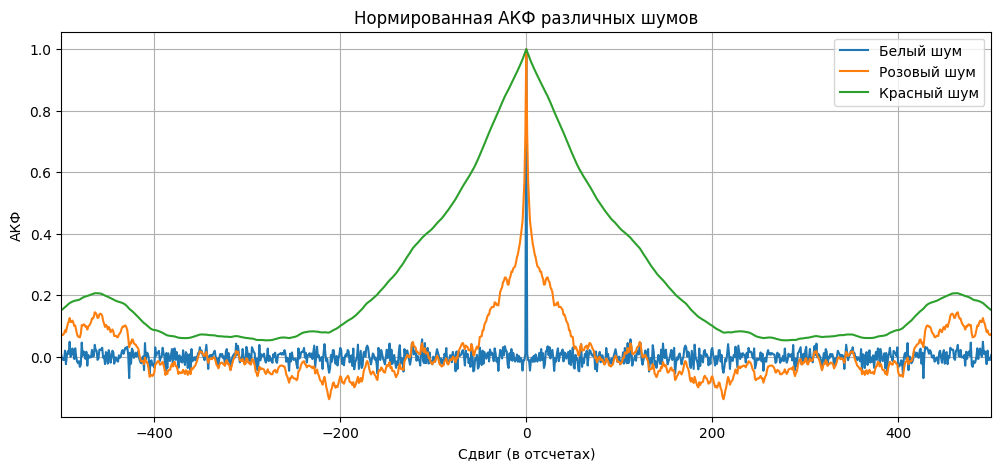

In [8]:

def acf_norm(x):
    corr = np.correlate(x, x, mode="full")
    corr = corr / np.max(corr)
    lags = np.arange(-len(x) + 1, len(x))
    return lags, corr

acf_data = {name: acf_norm(sig) for name, sig in noises.items()}

lag_limit = 500
plt.figure(figsize=(12, 5))
for name, (lags, corr) in acf_data.items():
    mask = np.abs(lags) <= lag_limit
    plt.plot(lags[mask], corr[mask], label=name)

plt.xlim(-500, 500)
plt.title("Нормированная АКФ различных шумов")
plt.xlabel("Сдвиг (в отсчетах)")
plt.ylabel("АКФ")
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


Форма АКФ напрямую связана с гладкостью сигнала: чем более гладким является сигнал, тем шире пик его АКФ и тем медленнее она спадает. Для белого шума АКФ имеет вид резкого пика в нуле (соседние отсчеты независимы). Для розового шума АКФ спадает медленнее, а для красного шума (самого гладкого сигнала) АКФ убывает предельно медленно из-за высокой зависимости каждого последующего отсчета от предыдущих.

## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


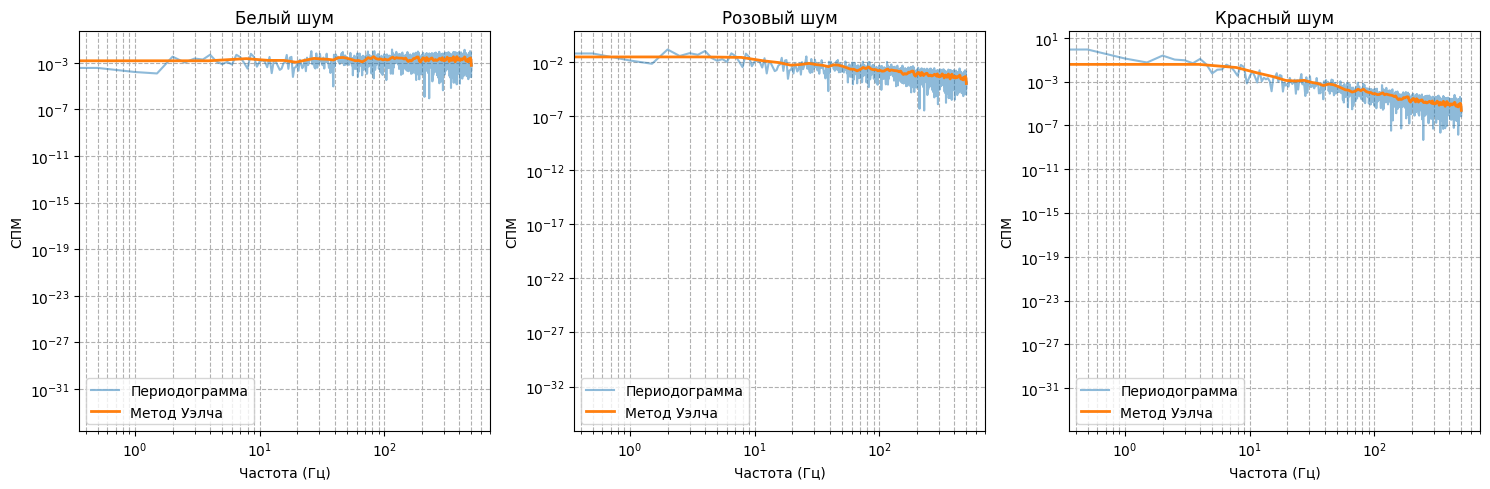

In [9]:
plt.figure(figsize=(15, 5))

for i, (name, noise) in enumerate(noises.items(), 1):
    f_per, Pxx_per = signal.periodogram(noise, fs)
    f_welch, Pxx_welch = signal.welch(noise, fs, nperseg=256, noverlap=128, window='hann')
    
    plt.subplot(1, 3, i)
    plt.loglog(f_per, Pxx_per, alpha=0.5, label='Периодограмма')
    plt.loglog(f_welch, Pxx_welch, linewidth=2, label='Метод Уэлча')
    plt.title(name)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('СПМ')
    plt.legend()
    plt.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


В двойном логарифмическом масштабе зависимости СПМ от частоты выглядят как прямые линии с разным наклоном. Теоретически, показатель степени $p$ в зависимости $y=x^p$ определяет наклон прямой на логарифмическом графике. Для белого шума спектр равномерный (горизонтальная линия, наклон 0). Для розового шума мощность убывает обратно пропорционально частоте ($1/f$), что дает наклон $-1$. Для красного шума мощность убывает как $1/f^2$, что соответствует наклону $-2$.

## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


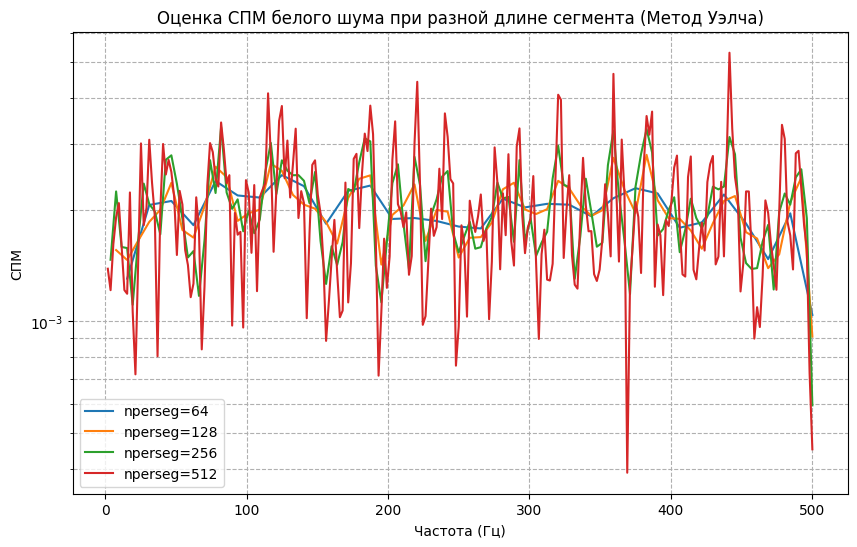

In [12]:
segments = [64, 128, 256, 512]

plt.figure(figsize=(10, 6))

for nperseg in segments:
    f_welch, Pxx_welch = signal.welch(white_noise,
                                      fs,
                                      nperseg=nperseg,
                                      noverlap=nperseg//2,
                                      window='hann')
    plt.semilogy(f_welch[1:], Pxx_welch[1:], label=f'nperseg={nperseg}')

plt.title("Оценка СПМ белого шума при разной длине сегмента (Метод Уэлча)")
plt.xlabel("Частота (Гц)")
plt.ylabel("СПМ")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


При увеличении длины сегмента улучшается частотное разрешение (пики становятся у́же, шаг по частоте уменьшается), однако ухудшается гладкость спектральной оценки (увеличивается дисперсия спектра). Это происходит потому, что при фиксированной длине сигнала бóльший размер сегмента приводит к меньшему числу усредняемых блоков.

## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

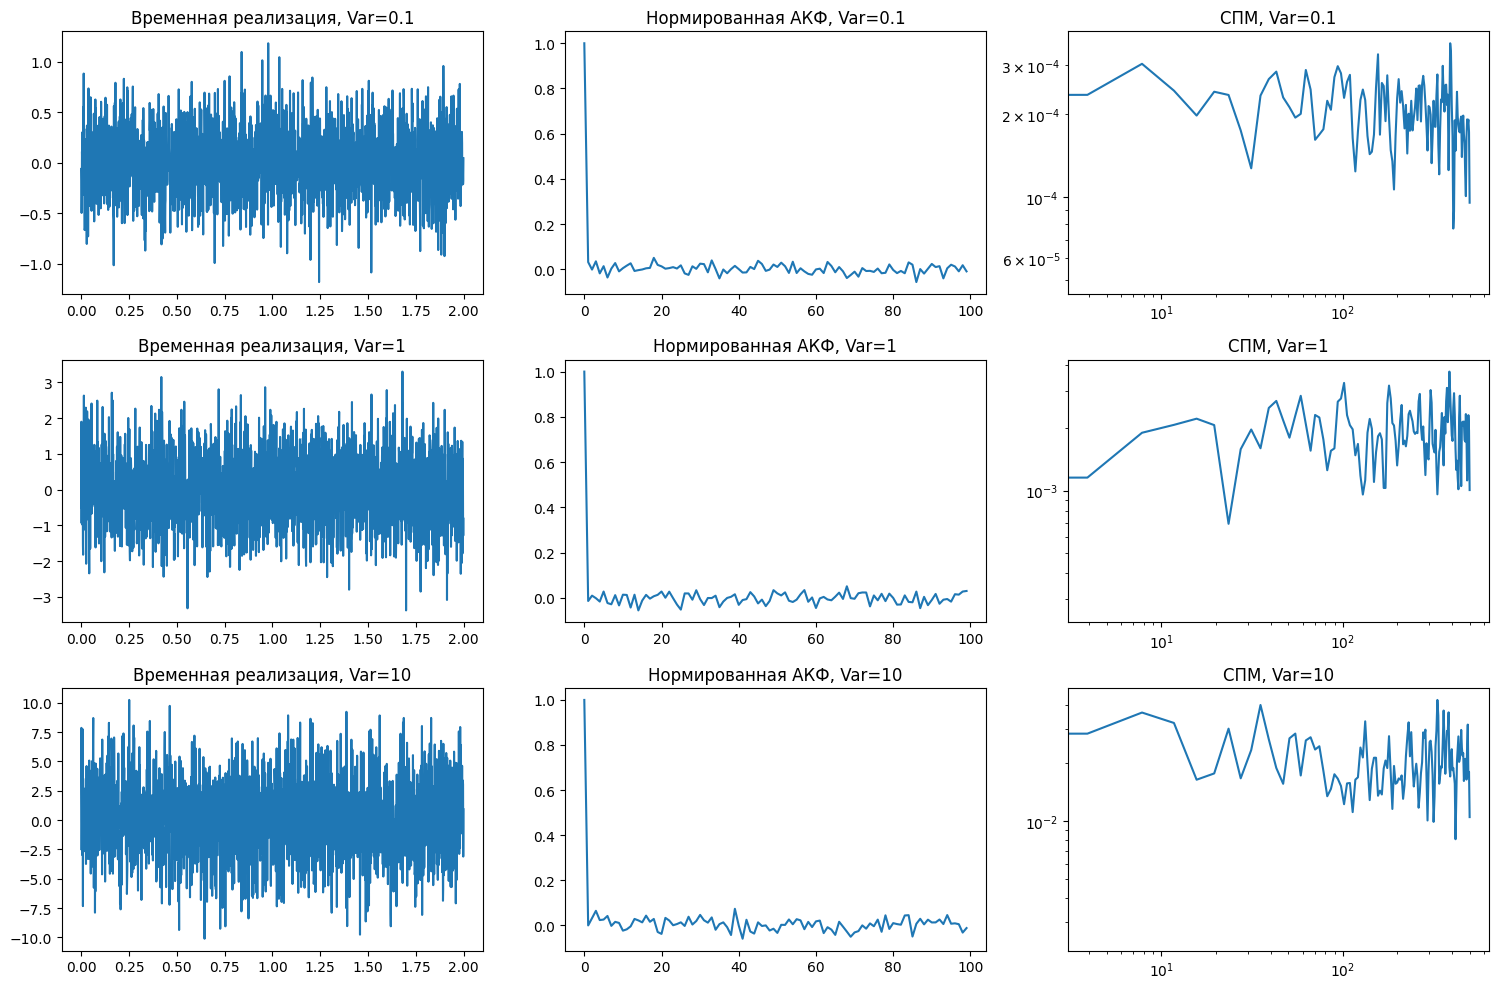

In [13]:
variances = [0.1, 1, 10]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for i, var in enumerate(variances):
    scale = np.sqrt(var)
    noise_var = np.random.normal(0, scale, N)
    
    axes[i, 0].plot(t, noise_var)
    axes[i, 0].set_title(f"Временная реализация, Var={var}")
    
    acf = np.correlate(noise_var, noise_var, mode='full')
    acf_normalized = acf[N-1:] / acf[N-1]
    axes[i, 1].plot(acf_normalized[:100])
    axes[i, 1].set_title(f"Нормированная АКФ, Var={var}")
    
    f_w, Pxx_w = signal.welch(noise_var, fs, nperseg=256, noverlap=128)
    axes[i, 2].loglog(f_w, Pxx_w)
    axes[i, 2].set_title(f"СПМ, Var={var}")
    
plt.tight_layout()
plt.show()

**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


При изменении дисперсии меняется амплитудный размах сигнала во временной области. На графике СПМ линия спектра сдвигается вверх или вниз (так как общая мощность сигнала изменяется пропорционально дисперсии). Нормированная АКФ при этом не меняется, поскольку она отражает только внутреннюю корреляционную структуру сигнала (зависимость отсчетов друг от друга), которая остается прежней вне зависимости от масштабирования амплитуд.


## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


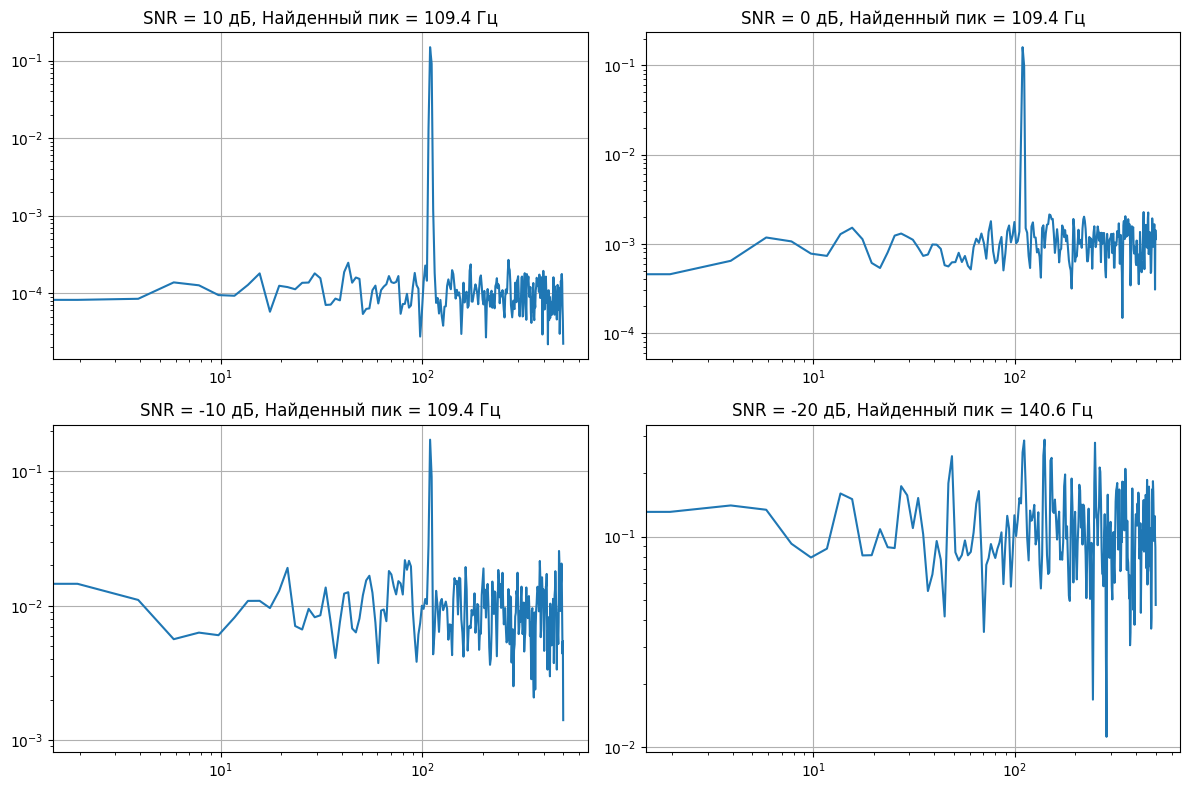

In [14]:
snr_db_list = [10, 0, -10, -20]
f_sine = 110
A = 1
P_sig = (A**2) / 2 # Мощность синусоиды

plt.figure(figsize=(12, 8))

for i, snr_db in enumerate(snr_db_list, 1):
    snr_lin = 10**(snr_db / 10)
    P_noise = P_sig / snr_lin
    noise = np.random.normal(0, np.sqrt(P_noise), N)
    
    sig = A * np.sin(2 * np.pi * f_sine * t) + noise
    
    f_w, Pxx_w = signal.welch(sig, fs, nperseg=512, noverlap=256, window='hann')
    
    plt.subplot(2, 2, i)
    plt.loglog(f_w, Pxx_w)
    
    # Нахождение пика
    peak_idx = np.argmax(Pxx_w)
    peak_freq = f_w[peak_idx]
    
    plt.title(f"SNR = {snr_db} дБ, Найденный пик = {peak_freq:.1f} Гц")
    plt.grid(True)

plt.tight_layout()
plt.show()

**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


С уменьшением SNR шумовая "полка" на графике СПМ поднимается выше, постепенно скрывая пик синусоиды. Тем не менее, из-за концентрации энергии гармонического сигнала в очень узком частотном диапазоне, пик можно визуально обнаружить даже при отрицательных значениях SNR (зачастую вплоть до $-10$ дБ или $-20$ дБ), поскольку спектральная плотность белого шума равномерно размазана по всем частотам.

## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


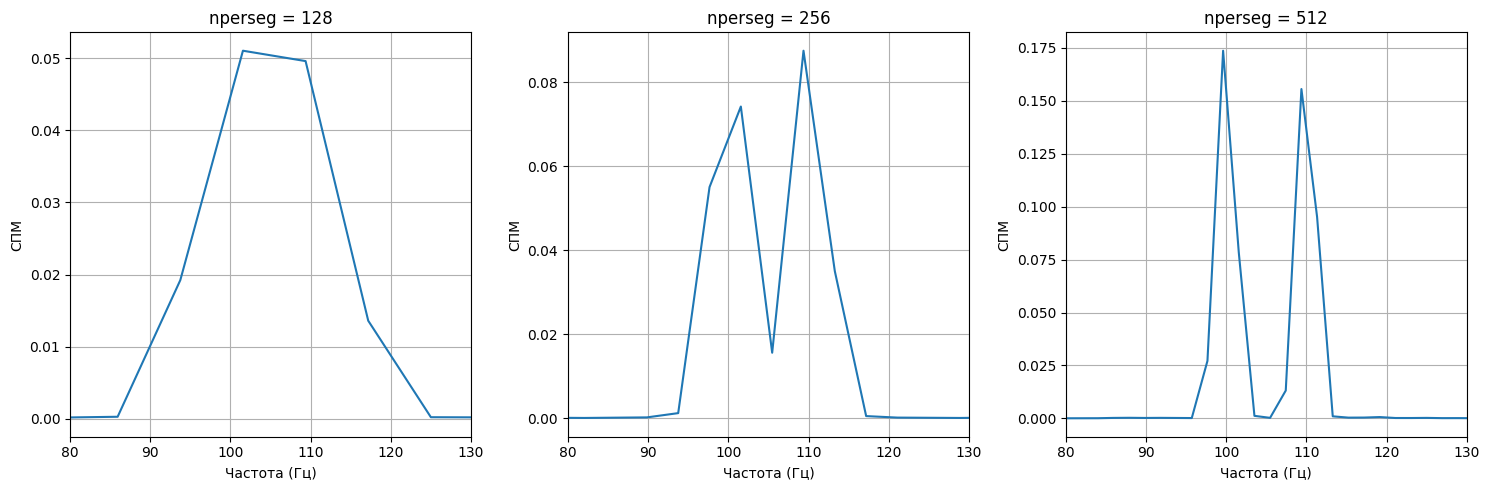

In [15]:
duration_1s = 1
N_1s = fs * duration_1s
t_1s = np.arange(N_1s) / fs

sig_two_sines = np.sin(2 * np.pi * 100 * t_1s) + np.sin(2 * np.pi * 110 * t_1s)
noise_01 = np.random.normal(0, np.sqrt(0.1), N_1s)
sig_combined = sig_two_sines + noise_01

nperseg_list = [128, 256, 512]

plt.figure(figsize=(15, 5))

for i, nperseg in enumerate(nperseg_list, 1):
    f_w, Pxx_w = signal.welch(sig_combined, fs, nperseg=nperseg, noverlap=nperseg//2, window='hann')
    
    plt.subplot(1, 3, i)
    plt.plot(f_w, Pxx_w)
    plt.xlim(80, 130)
    plt.title(f"nperseg = {nperseg}")
    plt.xlabel("Частота (Гц)")
    plt.ylabel("СПМ")
    plt.grid(True)

plt.tight_layout()
plt.show()

**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


В соответствии с теорией, частотное разрешение метода зависит от размера окна: $\Delta f \approx f_s / N_{seg}$. Для разделения частот в 100 Гц и 110 Гц необходимо разрешение лучше 10 Гц.
При nperseg = 128 разрешение составляет около 7.8 Гц. Теоретически этого достаточно, однако из-за применения оконной функции (Ханна), которая расширяет главный лепесток, пики практически сливаются. При nperseg = 256 ($\Delta f \approx 3.9$ Гц) и nperseg = 512 ($\Delta f \approx 1.9$ Гц) частоты уверенно разрешаются в виде двух независимых пиков.